In [1]:
!pip install pandas numpy matplotlib seaborn jieba wordcloud

In [2]:
# 查看 content_tag_dataset.txt 的前 5 行
with open('data/content_tag_dataset.txt', 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f.readline().strip())

双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过不用着急，小编现已帮你找好了性价比超级高的美衣，购物清单直接为各位列好啦！如果不列好自己的清单，东看看西看看	买鞋控:6.496;二手买家:0.1384;休闲大咖:1.2278;健美一族:0.8452;养生专家:4.440099999999999;吃货:6.3968;学霸:2.6002;家庭主妇:10.001300000000002;户外一族:1.0038;收纳达人:0.45470000000000005;数码达人:2.4281;时尚靓妹:7.209599999999999;有型潮男:0.8481999999999998;烹饪达人:5.6419999999999995;爱包人:2.1017;爱听音乐:3.6979;白富美:2.3716999999999997;美丽教主:7.625199999999999;职场办公:4.0028;花卉一族:0.09970000000000001;运动一族:2.3423999999999996;追风骑士:1.0803;速食客:1.8197999999999999;酒品人生:0.049499999999999995;阅读者:2.4834000000000005;高富帅:0.8591
不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣服难受不说，被别人看到了更是尴尬难受。在其他公众场合遇到此种情况的时候更是觉得丢脸，而且丧失了哺乳的乐趣，忧	买鞋控:2.7574000000000005;二手买家:1.2964;休闲大咖:0.0398;健美一族:1.6509;养生专家:0.7442;吃货:3.1656000000000004;家庭主妇:8.3234;情趣一族:0.10450000000000001;户外一族:1.3515;收纳达人:2.9181;收藏家:0.07100000000000001;数码达人:5.7072;时尚靓妹:5.037599999999999;烹饪达人:5.5756000000000006;爱包人:0.1674;爱听音乐:1.0870000000000002;白富美:2.1248;美丽教主:5.060099999999999;职场办公:2.2125;花卉一族:1.2874;运动一族:1.989

In [6]:
texts = []
with open('data/content_tag_dataset.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10000:  # 先取 1 万条
            break
        parts = line.strip().split('\t')
        if len(parts) >= 1 and parts[0]:
            texts.append(parts[0])  # 第一列就是文本

df = pd.DataFrame(texts, columns=['raw_text'])
df.head()

,raw_text
0,双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过...
1,不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣...
2,茶水是中国最传统的饮品之一，同时饮茶也是中国的传统文化之一。不管是开心还是难过，不管是吵闹还...
3,氛围轻松、色调清新的北欧家装风格，总是给人的感觉非常轻松。用它来作为客厅空间的主角，即使简单...
4,对于很多的家庭来说，卧室的装扮总是要多费一些心思的，毕竟是一天当中花费时间最多的地方。整个卧...


In [7]:
import re

def clean_text(text):
    # 去除表情符号、特殊符号（保留中文、英文、数字、常用中文标点）
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9，。！？、；：“”‘’（）【】《》]', ' ', text)
    # 将连续多个空格合并为一个
    text = re.sub(r'\s+', ' ', text)
    # 去除首尾空格
    text = text.strip()
    if len(text) > 50:
        text = text[:50]
    return text

df['cleaned_text'] = df['raw_text'].apply(clean_text)

df[['raw_text', 'cleaned_text']].head()

,raw_text,cleaned_text
0,双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过...,双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过...
1,不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣...,不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣...
2,茶水是中国最传统的饮品之一，同时饮茶也是中国的传统文化之一。不管是开心还是难过，不管是吵闹还...,茶水是中国最传统的饮品之一，同时饮茶也是中国的传统文化之一。不管是开心还是难过，不管是吵闹还...
3,氛围轻松、色调清新的北欧家装风格，总是给人的感觉非常轻松。用它来作为客厅空间的主角，即使简单...,氛围轻松、色调清新的北欧家装风格，总是给人的感觉非常轻松。用它来作为客厅空间的主角，即使简单...
4,对于很多的家庭来说，卧室的装扮总是要多费一些心思的，毕竟是一天当中花费时间最多的地方。整个卧...,对于很多的家庭来说，卧室的装扮总是要多费一些心思的，毕竟是一天当中花费时间最多的地方。整个卧...


In [8]:
# 简单停用词表（可手动添加电商常见无意义词，如“包邮”、“正品”等）
stopwords = set([
    '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个', 
    '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', 
    '自己', '这', '那', '吗', '吧', '啊', '哦', '嗯', '我们', '可以', '就是', '因为', 
    '所以', '但是', '如果', '什么', '怎么', '这么', '怎么', '这个', '那个', '这些', 
    '那些', '然后', '之后', '以上', '以下', '我们', '你们', '他们', '她', '他', '它'
])

In [9]:
import jieba

def segment(text):
    # 使用 jieba 精确模式分词
    words = jieba.lcut(text)
    # 过滤停用词和单字
    words = [w for w in words if w not in stopwords and len(w) > 1]
    return words

df['words'] = df['cleaned_text'].apply(segment)

# 查看分词效果
df[['cleaned_text', 'words']].head(10)

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\liuzi\AppData\Local\Temp\jieba.cache
Loading model cost 1.002 seconds.
Prefix dict has been built successfully.


,cleaned_text,words
0,双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过...,"[双十, 目前, 优惠活动, 现已, 出来, 许多, 那么, 活动, 真实, 目不暇接, 目..."
1,不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣...,"[不少, 妈咪, 遇到, 这样, 问题, 尤其, 哺乳, 期间, 随时随地, 担心, 不会,..."
2,茶水是中国最传统的饮品之一，同时饮茶也是中国的传统文化之一。不管是开心还是难过，不管是吵闹还...,"[茶水, 中国, 传统, 饮品, 之一, 同时, 饮茶, 中国, 传统, 文化, 之一, 不..."
3,氛围轻松、色调清新的北欧家装风格，总是给人的感觉非常轻松。用它来作为客厅空间的主角，即使简单...,"[氛围, 轻松, 色调, 清新, 北欧, 家装, 风格, 总是, 感觉, 非常, 轻松, 作..."
4,对于很多的家庭来说，卧室的装扮总是要多费一些心思的，毕竟是一天当中花费时间最多的地方。整个卧...,"[对于, 很多, 家庭, 来说, 卧室, 装扮, 总是, 多费, 一些, 心思, 毕竟, 一..."
5,人人都爱穿搭的今天，鞋子对一个人整体造型感的重要性不言而喻。俗语说：想知道一个人是否过得精致...,"[人人, 今天, 鞋子, 整体, 造型, 重要性, 不言而喻, 俗语说, 知道, 是否, 过..."
6,上班族的下午并不轻松，不论是源源不断的工作还是下午身体所能感受到的疲累，都是不小的挑战。为了...,"[上班族, 下午, 轻松, 不论是, 源源不断, 工作, 还是, 下午, 身体, 感受, 疲..."
7,在客厅上铺地毯，把客厅的家具包裹在内，这样做的目的不是让客厅显得更大，而是把会客区域收缩到一...,"[客厅, 上铺, 地毯, 客厅, 家具, 包裹, 在内, 这样, 目的, 不是, 客厅, 显..."
8,中年心事浓如酒 少女情怀总是诗。少女感除了靠俏皮妆容打造，也可以通过可爱甜美的穿搭来get。...,"[中年, 心事, 浓如酒, 少女, 情怀, 总是, 少女, 除了, 俏皮, 妆容, 打造, ..."
9,一双靴子，却能穿出高大上的感觉。谁说靴子只是女士们的专属？男士们照样能驾驭。只要选对了靴子，...,"[一双, 靴子, 高大, 感觉, 靴子, 只是, 女士们, 专属, 男士们, 照样, 驾驭,..."


In [10]:
from collections import Counter

# 将所有词语合并成一个列表
all_words = []
for words in df['words']:
    all_words.extend(words)

word_counts = Counter(all_words)

# 输出高频词 Top 20
print("高频词 Top 20：")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

高频词 Top 20：
很多: 955
时尚: 934
对于: 623
搭配: 589
生活: 573
时候: 551
单品: 503
还是: 497
宝宝: 474
已经: 460
来说: 446
一件: 443
选择: 442
风格: 431
女生: 428
设计: 424
喜欢: 418
季节: 418
不仅: 415
大家: 409


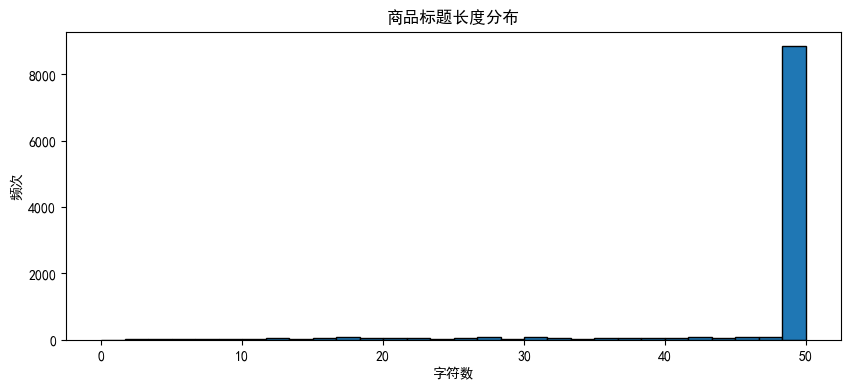

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['SimHei']   # 或 ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 计算每个清洗后文本的长度
df['text_length'] = df['cleaned_text'].apply(len)

plt.figure(figsize=(10, 4))
plt.hist(df['text_length'], bins=30, edgecolor='black')
plt.title('商品标题长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')
plt.show()

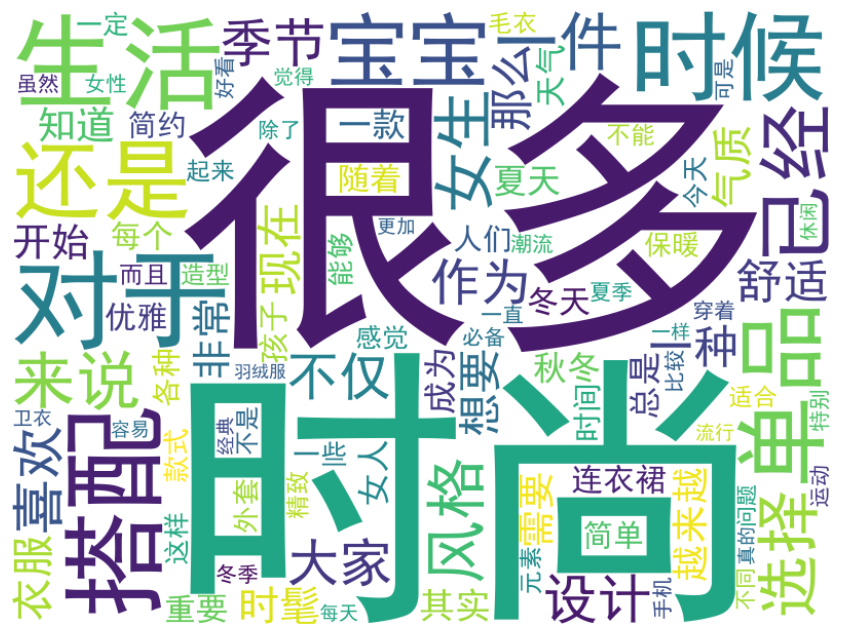

In [12]:
from wordcloud import WordCloud

# 准备词频字典（取前 100 个高频词）
word_freq = dict(word_counts.most_common(100))

# 生成词云
wc = WordCloud(
    font_path='C:/Windows/Fonts/simhei.ttf',   # Windows 中文字体路径
    width=800,
    height=600,
    background_color='white'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [14]:
df.to_csv('data/processed/cleaned_titles.csv', index=False, encoding='utf-8-sig')